# Statistics of NMRlipids databank

This notebook plots:
1. Distributions of simulation lengths, number of atoms and trajectory sizes
2. Distribution of number of lipid components
3. Available single component bilayers and binary lipid mixtures
4. Pie diagram of temperatures

# Initializing databank

In [1]:
from DatabankLib.protein_functions import *
import yaml

#databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"



# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()


/home/sosamuli/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations


In [2]:
for system in systems:
    print(system)

System(119): d02/dcf/d02dcfaaecf4ca9eadb12bfa047b8f0388c744c6/0db7a9f05c27cbc152110cbd562bec2d201ccf06/
System(26): 591/0c7/5910c7a9f3a841dfafd047dc3b509a00c214f140/0b83ddddf9f2e8ecac81dcaa7fef667472d28184/
System(96): c8a/f55/c8af5520531bad6d0040961170e6a8ba1fe76014/bf38f916a33d4af177646ebdd257f293fb04aa0c/
System(130): a47/416/a47416e44ba9ebece8aa9136736d7b43611cc554/361fa94d8e81de8ac1e30e9db306cb1148ec7c44/
System(49): bf3/0ed/bf30ed6d666efbcbf25af9c75ea0b820f1584bf6/f68e66dbd16cbc101bbfa34d3f9a1613166434a4/
System(79): a02/63c/a0263cccccb94ac769a50f128dd566f27a12216f/e6f23f69d25f4bb156c8051587567f1c85a8648a/
System(13): 177/415/1774152d093244b14fe1aed51284089c812174cd/d47413ba289f58dcd92b3ac753e222dd910bd04e/
System(135): 95a/41b/95a41b30aa70b50a1a193031f46c2832e94d4b40/1ede1e35b6a3e3c7b9de1f34c18b5b253cef7fdc/
System(172): f27/30d/f2730dcd274f4b31cab34cf9c7f7fbfd3fbbcd54/8c8ce7913551266310fd934f6f40a50381f14111/
System(87): f27/981/f27981c4bde82a195ed77bed88eb0cc45699e96f/5b0d5aea

# Plot distributions of simulation lengths, number of atoms and trajectory sizes

Number of entries:  238
Total size of trajectories:  270.9569613337517 Gb
Total time of trajectories:  421984.36999999994 ns


Text(0, 0.5, 'Distribution')

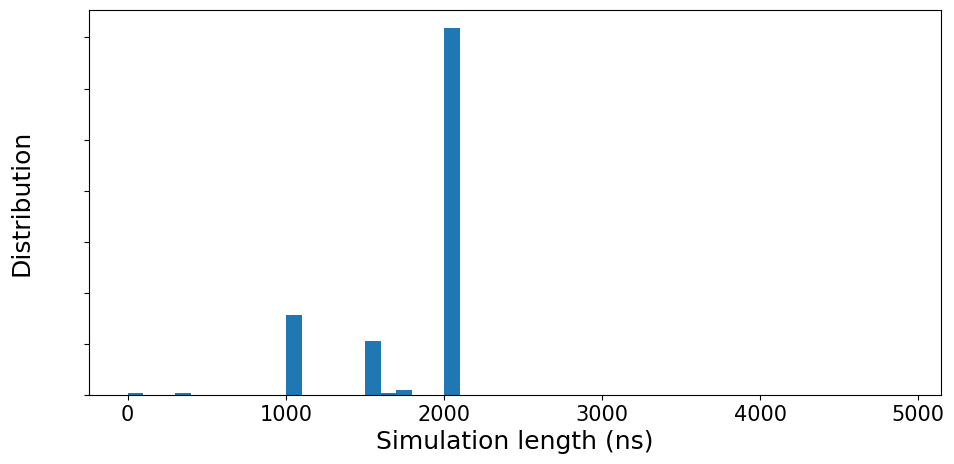

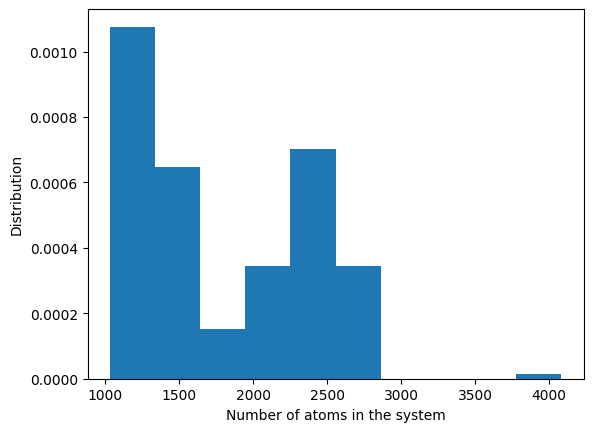

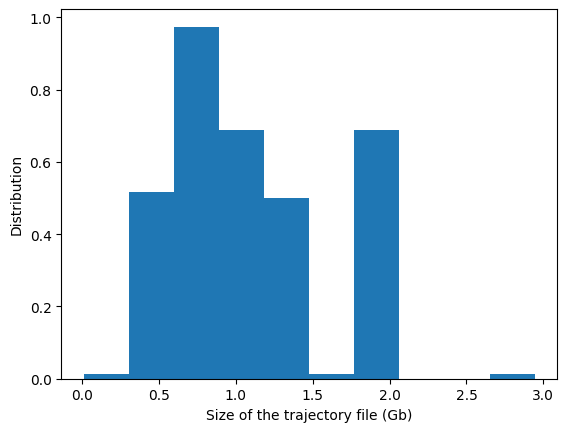

In [2]:
SimulationLengths = []
NumberOfAtoms = []
SizeOfTrajectories = []

# Loop over simulations in the Databank
for system in systems:
    SimulationLengths.append(system['TRJLENGTH']*0.001)
    NumberOfAtoms.append(system['NUMBER_OF_ATOMS'])
    SizeOfTrajectories.append(system['TRAJECTORY_SIZE']/(1024*1024*1024))
    
print("Number of entries: ",len(systems))
print("Total size of trajectories: ",str(np.sum(SizeOfTrajectories)) + ' Gb')
print("Total time of trajectories: ",str(np.sum(SimulationLengths)) + ' ns')

plt.figure(figsize=(11,5))
distSIMl = plt.hist(SimulationLengths, density=True,bins=np.arange(0,5000,100))
plt.xlabel('Simulation length (ns)', fontsize=18)
plt.ylabel('Distribution', fontsize=18)
plt.yticks(color='w')
plt.xticks(fontsize=15)
plt.figure()
distNatoms = plt.hist(NumberOfAtoms, density=True)
plt.xlabel('Number of atoms in the system')
plt.ylabel('Distribution')
plt.figure()
disttrjSIZE = plt.hist(SizeOfTrajectories, density=True)
plt.xlabel('Size of the trajectory file (Gb)')
plt.ylabel('Distribution')

# Plot distribution of different proteins

{'asyn_salt': 25, 'KRS1-72': 25, 'icl2': 25, 'ChiZ_salt': 25, 'asyn': 25, 'KRS1-72_salt': 25, 'ChiZ1-64': 25, 'TonBCTD': 10, 'wrapping silk (AcSp1)': 25, 'calmodulin': 25, 'Calmodulin': 1, 'TonB': 1, 'EN2': 1}


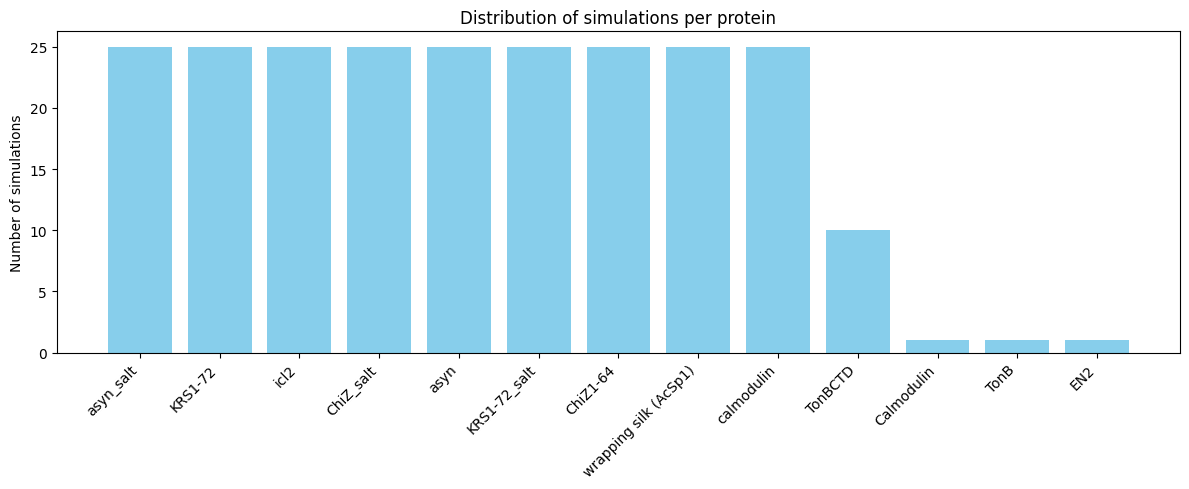

In [7]:
# Loop over simulations in the Databank

system_descriptions = {}

for system in systems:
    #print(system['COMPOSITION']['PROTEIN']['SEQUENCE'])
    system_description = system['SYSTEM']
    if system_description not in system_descriptions:
        system_descriptions[system_description] = 1
    else:
        system_descriptions[system_description] += 1
    
    #print(system['FF'])
print(system_descriptions)
    
# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(12,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per protein")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot distribution of different force fields

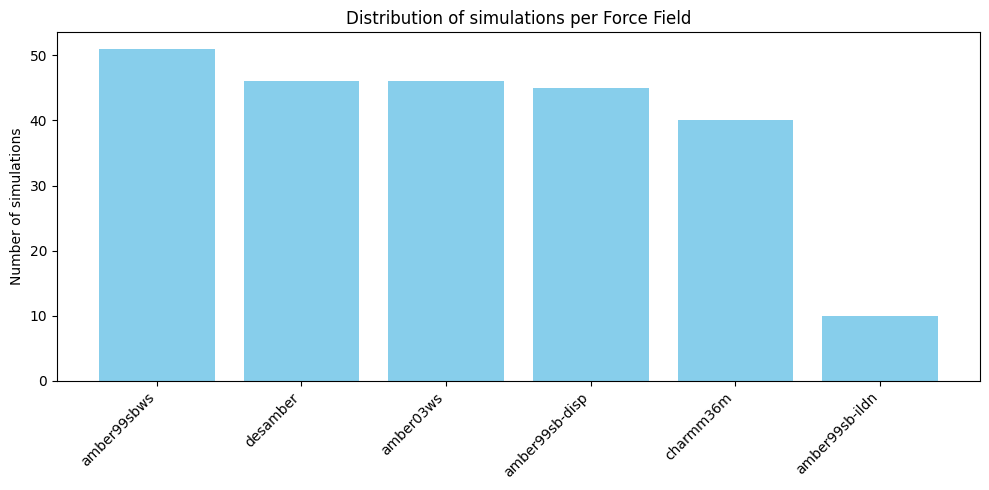

In [9]:
import matplotlib.pyplot as plt

# Mapping of variant names to canonical force field names
ff_canonical = {
    'amberff03ws': 'amber03ws',
    'amber03ws': 'amber03ws',
    'amber99sbws': 'amber99sbws',
    'amber99sb-disp': 'amber99sb-disp',
    'desamber': 'desamber',
    'charmm36m': 'charmm36m',
}

# Count simulations per (canonical) force field
system_descriptions = {}

for system in systems:
    ff = str(system['FF']).strip().lower()  # normalize
    ff = ff_canonical.get(ff, ff)          # map to canonical name
    
    if ff in ['none','nan','unknown']:
        continue  # skip invalid FFs
    
    if ff not in system_descriptions:
        system_descriptions[ff] = 1
    else:
        system_descriptions[ff] += 1

# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(10,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per Force Field")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

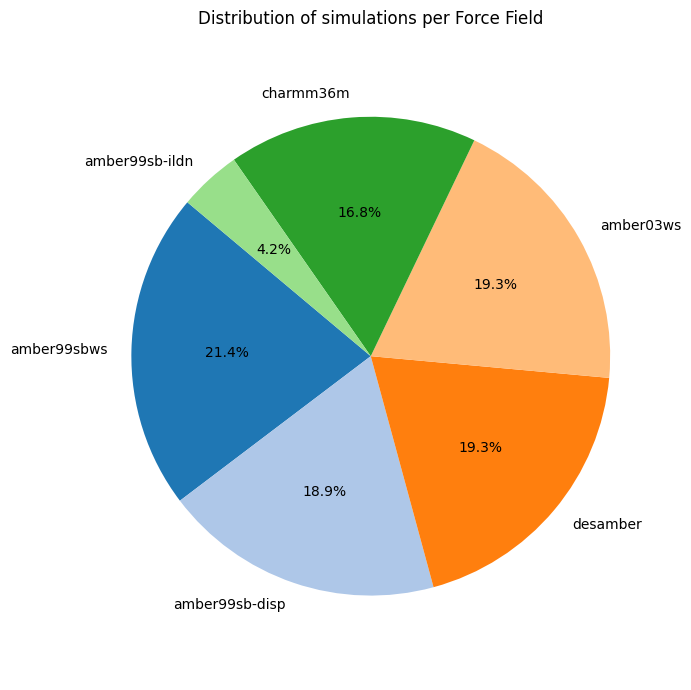

In [10]:
import matplotlib.pyplot as plt

# Use the same system_descriptions dictionary from your previous step
labels = list(system_descriptions.keys())
sizes = list(system_descriptions.values())

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Distribution of simulations per Force Field")
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular
plt.tight_layout()
plt.show()

# Plot systems with experimental data available

In [17]:
# Loop over simulations in the Databank
for system in systems:
    print(system['EXPERIMENT'])

{'chemical_shift': {'alignment_score': [661.0, 661.0, 661.0, 661.0, 661.0], 'ionic_strength': [0.095, 0.02, 0.02, 0.0, 0.0], 'ionic_strength_match': [True, False, False, False, False], 'path': ['BMRBid16300', 'BMRBid16543', 'BMRBid52093', 'BMRBid19257', 'BMRBid26557'], 'ph': [7.4, 6.0, 7.0, 6.2, 7.0], 'ph_match': [True, False, True, False, True], 'sequence': ['MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA', 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA', 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA', 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA', 'MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKE

# Plotting pie diagram of temperatures

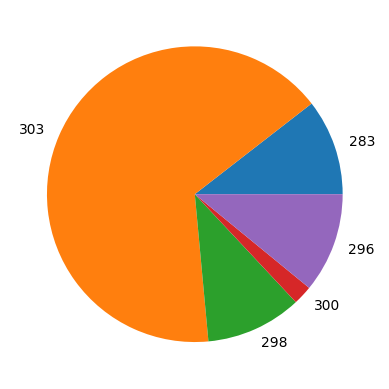

In [11]:
#db_data.pie_temperature()
import collections
temps = [ int(float(system['TEMPERATURE'])) for system in systems]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

<Figure size 640x480 with 0 Axes>

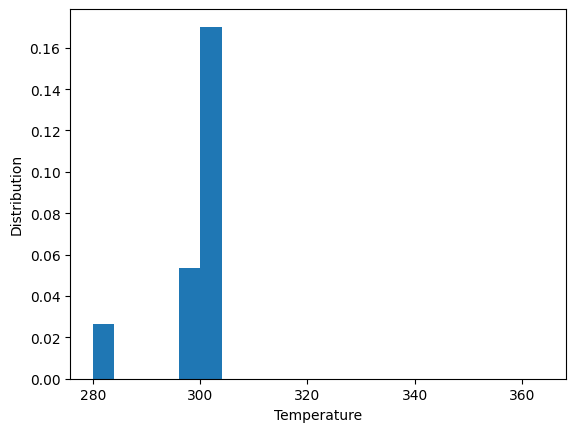

<Figure size 640x480 with 0 Axes>

In [12]:
distTemps = plt.hist(temps, density=True, bins=np.arange(280,365,4))
plt.xlabel('Temperature')
plt.ylabel('Distribution')
plt.figure()

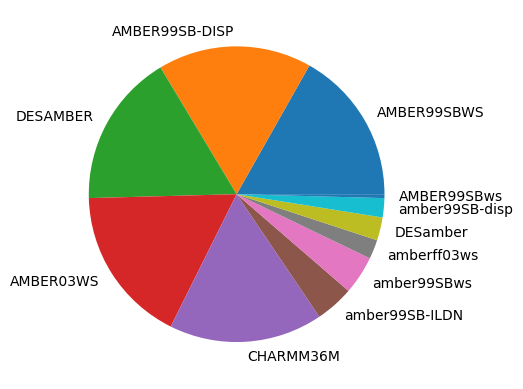

In [13]:

temps = [ s['FF'] for s in systems if 'FF' in s]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

Force field information missing froma7f/9f3/a7f9f36feaa77791483dadb0157f86a6a519f2c3/a30f01e8771c44dc59b78753d1dd27ca67920e38/
Force field information missing fromc04/cdb/c04cdb61143bb72ba2ddee11599e6bbfaf6cb211/a31f42800216d84d2242eae2af8ac2cbd6b033ee/
{'Orange': 5, 'Poger': 4, 'GAFFlipid': 3, 'OpenFF': 4, 'Ulmschneider': 2, 'GROMOS 43A1-S3': 2, 'OPLS3e': 4, 'Chiu Gromos': 1, 'ECC-CHARMM36': 3}


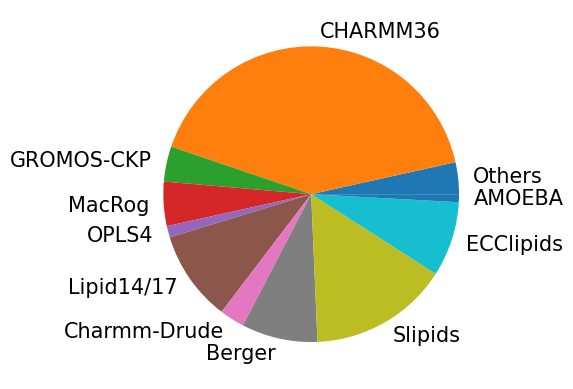

In [12]:
ffs = []

for system in systems:
    try:
        ff = system['FF']
    except:
        print('Force field information missing from' + system['path'])
    
    if 'GROMOS-CKP' in ff or 'gromos-ckp' in ff:
        ffs.append('GROMOS-CKP')
    elif 'Charmm-Drude' in ff:
        ffs.append('Charmm-Drude')
    elif 'Berger' in ff:
        ffs.append('Berger')    
    elif 'Slipids' in ff or 'slipids' in ff:
        ffs.append('Slipids')    
    elif 'lipid17ecc' in ff or 'ECC-lipids' in ff:
        ffs.append('ECClipids')
    elif 'ECC-CHARMM36' in ff:
        ffs.append(ff)
    elif 'CHARMM36' in ff or 'Charmm36' in ff:
        ffs.append('CHARMM36')
    elif 'Lipid14' in ff or 'Lipid17' in ff or 'lipid17' in ff:
        ffs.append('Lipid14/17')
    elif 'Poger' in ff:
        ffs.append('Poger')
    else:
        ffs.append(ff)
    
counter = collections.Counter(ffs)
several = {}
several['Others'] = 0
less = {}
for i in counter:
    if counter[i] > 5:
        several[i] = counter[i]
    else:
        several['Others'] += counter[i] 
        less[i] = counter[i]
#plt.pie(counter.values(),labels=counter.keys(), textprops={'fontsize': 15});
plt.pie(several.values(),labels=several.keys(), textprops={'fontsize': 15});
#plt.savefig('../../../DataBankManuscriptText/Figures/FFpie.pdf', bbox_inches='tight')
print(less)

{'DPPE': 3, 'TMCL': 1, 'BOG': 4, 'CER': 5, 'DOG': 4, 'DYPC': 3, 'SAPI25': 6, 'DLIPC': 6, 'SDPE': 4, 'PYPC': 3, 'DSPC': 2, 'DRPC': 3, 'TLCL_0H': 4, 'DCHOL': 2, 'SLiPC': 3, 'SM18': 2, 'DPPG': 2, 'POPI': 2, 'CER180': 1, 'DDOPC': 2, 'DEPC': 1, 'SDG': 4, 'C30': 1, 'DPPGK': 1, 'GB3': 1, 'GM1': 3, 'SAPI': 1, 'SLPI': 1, 'PAzePCdeprot': 1, 'PAzePCprot': 1, 'SAPI24': 1}


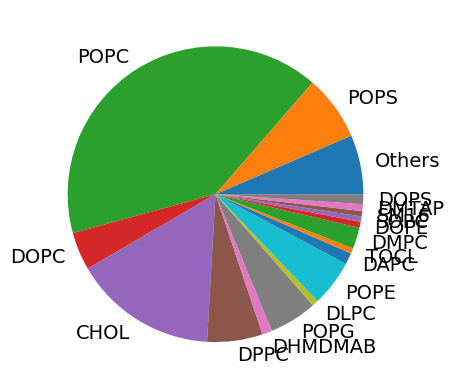

In [13]:
lipids = []
for system in systems:
    for lipid in system['COMPOSITION']:
        if lipid in lipids_set:
            lipids.append(lipid)
counter = collections.Counter(lipids)
several = {}
several['Others'] = 0
less = {}
for i in counter:
    if counter[i] > 6:
        several[i] = counter[i]
    else:
        several['Others'] += counter[i] 
        less[i] = counter[i]

#plt.figure(figsize=(11,5))
plt.pie(several.values(),labels=several.keys(), textprops={'fontsize': 14});
#plt.savefig('../../../DataBankManuscriptText/Figures/FFlipids.pdf', bbox_inches='tight')
print(less)